# Insurance Claims Monte Carlo Simulation Notebook

# Introduction

In this project, we analyze insurance claim severity and aggregate losses using a Monte Carlo simulation framework. The goal is to estimate expected losses and risk measures such as Value at Risk (VaR), which are commonly used in actuarial pricing and risk management.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

In [ ]:
url = "https://raw.githubusercontent.com/xaznweix/Insurance-dataset/f5513ce5989935009d1754ad018f09bf8fff1f14/AutoBi.csv"
AutoBI = pd.read_csv(url)
AutoBI.head()

,Index,CASENUM,ATTORNEY,CLMSEX,MARITAL,CLMINSUR,SEATBELT,CLMAGE,LOSS
0,1,5,1,1.0,NaN,2.0,1.0,50.0,34.940
1,2,13,2,2.0,2.0,1.0,1.0,28.0,10.892
2,3,66,2,1.0,2.0,2.0,1.0,5.0,0.330
3,4,71,1,1.0,1.0,2.0,2.0,32.0,11.037
4,5,96,2,1.0,4.0,2.0,1.0,30.0,0.138


In [ ]:
# ── Clean: drop nulls in key columns ────────────────────────────────
loss     = AutoBI["LOSS"].dropna()

# Explanatory Data Analysis

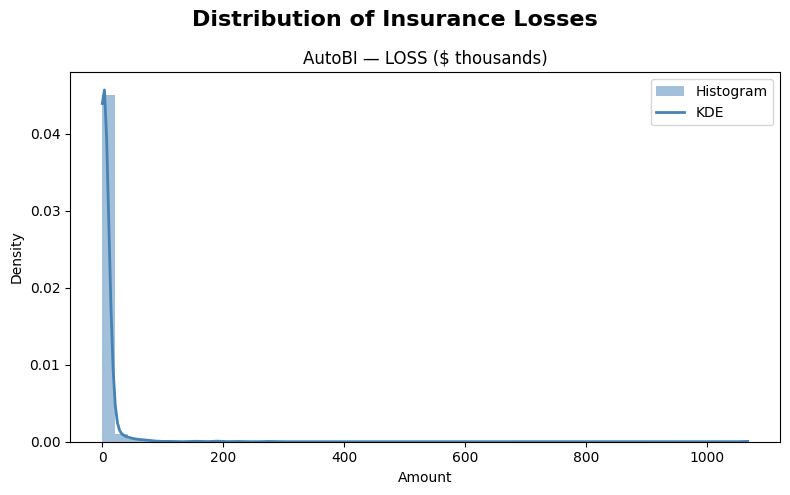

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

fig, ax = plt.subplots(figsize=(8, 5))

fig.suptitle(
    "Distribution of Insurance Losses",
    fontsize=16,
    fontweight="bold"
)

# Histogram
ax.hist(
    loss,
    bins=50,
    density=True,
    alpha=0.5,
    color="steelblue",
    label="Histogram"
)

# KDE curve
kde = stats.gaussian_kde(loss)
x = np.linspace(loss.min(), loss.max(), 300)

ax.plot(
    x,
    kde(x),
    color="steelblue",
    linewidth=2,
    label="KDE"
)

# Labels
ax.set_title("AutoBI — LOSS ($ thousands)")
ax.set_xlabel("Amount")
ax.set_ylabel("Density")
ax.legend()

plt.tight_layout()
plt.savefig("distributions_hist_kde.png", dpi=150)
plt.show()

From the plot, it looks like AutoBI is extremely right skewed.
AutoClaims is also extremely right skewed as well.
AutoCollision is mild skewed.

The implied mean for lognormal is e^( mu + 0.5*sigma^2)

In [ ]:
# for this we are fitting a lognormal distribution on AutoBI loss because it is right skewed.

loss = loss[loss > 0]  # lognormal requires strictly positive values

# ── Fit lognormal ──────────────────────────────────────────────────
# scipy returns (shape=sigma, loc=shift, scale=exp(mu))
sigma, loc, scale = stats.lognorm.fit(loss, floc=0)  # floc=0 fixes location at 0

mu = np.log(scale)   # convert scale back to mu

print(f"Fitted μ (mu):    {mu:.4f}")
print(f"Fitted σ (sigma): {sigma:.4f}")
print(f"Implied median:   ${np.exp(mu):.2f}k")
print(f"Implied mean:     ${np.exp(mu + 0.5*sigma**2):.2f}k")

Fitted μ (mu):    0.5567
Fitted σ (sigma): 1.4779
Implied median:   $1.74k
Implied mean:     $5.20k


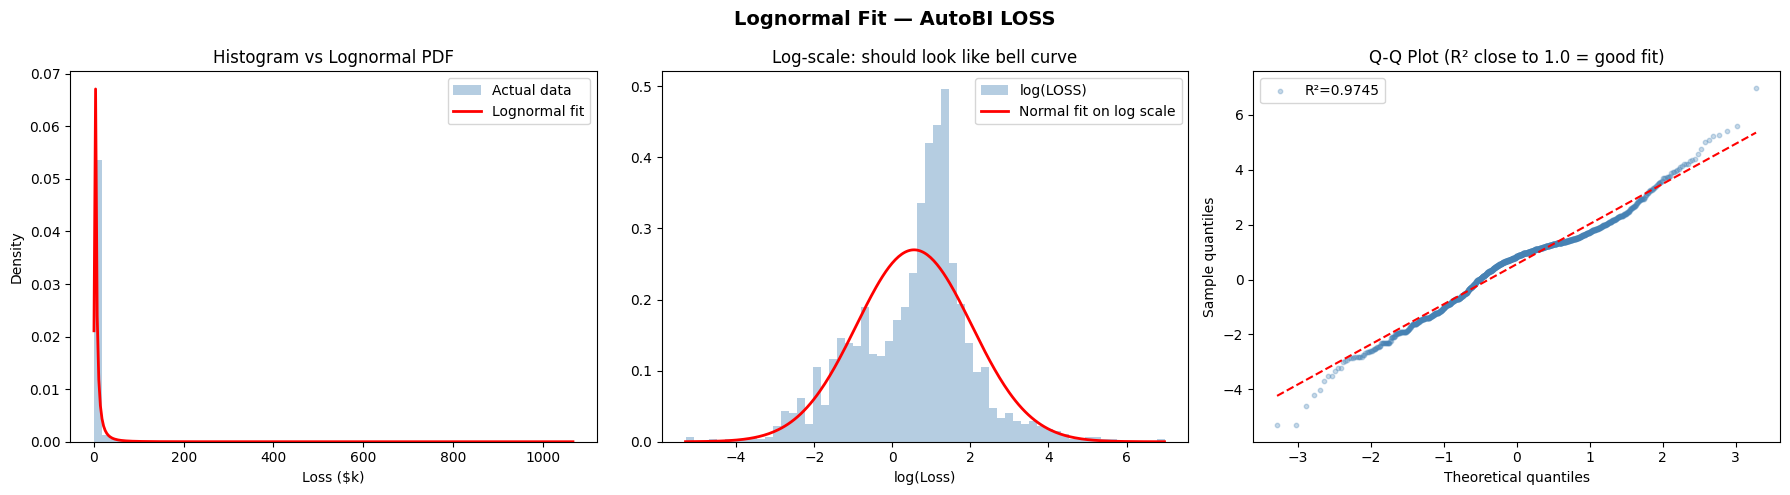

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Lognormal Fit — AutoBI LOSS", fontsize=14, fontweight="bold")

x = np.linspace(loss.min(), loss.max(), 300)
pdf_fitted = stats.lognorm.pdf(x, s=sigma, loc=0, scale=scale)

# Plot 1 — Histogram vs fitted curve
axes[0].hist(loss, bins=60, density=True, alpha=0.4,
             color="steelblue", label="Actual data")
axes[0].plot(x, pdf_fitted, "r-", linewidth=2, label="Lognormal fit")
axes[0].set_title("Histogram vs Lognormal PDF")
axes[0].set_xlabel("Loss ($k)")
axes[0].set_ylabel("Density")
axes[0].legend()

# Plot 2 — Same on log scale (more informative)
log_loss = np.log(loss)
axes[1].hist(log_loss, bins=60, density=True, alpha=0.4,
             color="steelblue", label="log(LOSS)")
x_log = np.linspace(log_loss.min(), log_loss.max(), 300)
axes[1].plot(x_log, stats.norm.pdf(x_log, mu, sigma),
             "r-", linewidth=2, label="Normal fit on log scale")
axes[1].set_title("Log-scale: should look like bell curve")
axes[1].set_xlabel("log(Loss)")
axes[1].legend()

# Plot 3 — Q-Q plot (definitive goodness-of-fit test)
(osm, osr), (slope, intercept, r) = stats.probplot(log_loss, dist="norm")
axes[2].scatter(osm, osr, alpha=0.3, color="steelblue", s=10, label=f"R²={r**2:.4f}")
axes[2].plot(osm, slope*np.array(osm)+intercept, "r--", linewidth=1.5)
axes[2].set_title("Q-Q Plot (R² close to 1.0 = good fit)")
axes[2].set_xlabel("Theoretical quantiles")
axes[2].set_ylabel("Sample quantiles")
axes[2].legend()

plt.tight_layout()
plt.show()

In the first figure, we see that the lognormal fit is close to the actual data.
In the second figure, we see that the distribution much more symmetric after the log transformation and it looks approximately bell shaped.
In the third figure, we see that points mostly follow a straight line and that the R^2 value is pretty close to 1.


# Splitting Attorney vs non-attorney

In [ ]:
# Fit separate distributions per group
attorney     = AutoBI[AutoBI["ATTORNEY"] == 1]["LOSS"]
no_attorney  = AutoBI[AutoBI["ATTORNEY"] == 2]["LOSS"]

# Fit lognormal to each
sig_att,  _, scale_att  = stats.lognorm.fit(attorney,    floc=0)
sig_natt, _, scale_natt = stats.lognorm.fit(no_attorney, floc=0)

In [ ]:
# Interpret the results
print("=== Attorney-represented claims ===")
print(f"sigma:          {sig_att:.4f}")
print(f"median loss:    ${np.exp(np.log(scale_att)):.2f}k")
print(f"implied mean:   ${np.exp(np.log(scale_att) + 0.5*sig_att**2):.2f}k")

print("\n=== Non-attorney claims ===")
print(f"sigma:          {sig_natt:.4f}")
print(f"median loss:    ${np.exp(np.log(scale_natt)):.2f}k")
print(f"implied mean:   ${np.exp(np.log(scale_natt) + 0.5*sig_natt**2):.2f}k")

=== Attorney-represented claims ===
sigma:          1.2448
median loss:    $3.49k
implied mean:   $7.58k

=== Non-attorney claims ===
sigma:          1.3482
median loss:    $0.84k
implied mean:   $2.10k


It looks like the attorney represented claims have a higher median loss and a higher implied mean.
The surprising thing is that the sigma (standard deviation) is higher for the non-attorney claims.
We will try to simulate monte carlo simulation for the loss when a client is represented by an attorney.

In [ ]:
n_simulations = 10_000

# What fraction of claims involve attorneys?
p_attorney = len(attorney) / len(AutoBI)
print(f"Attorney involvement rate: {p_attorney:.1%}")

total_losses = []

for _ in range(n_simulations):
    n_total = 100  # expected claims in a year

    # Split into attorney vs non-attorney
    n_att  = np.random.binomial(n_total, p_attorney)
    n_natt = n_total - n_att

    # Draw losses from each population separately
    losses_att  = stats.lognorm.rvs(s=sig_att,  scale=scale_att,  size=n_att)
    losses_natt = stats.lognorm.rvs(s=sig_natt, scale=scale_natt, size=n_natt)

    total = np.sum(losses_att) + np.sum(losses_natt)
    total_losses.append(total)

total_losses = np.array(total_losses)

print(f"\nMonte Carlo Results (split by attorney)")
print(f"Mean expected loss:     ${total_losses.mean():.2f}k")
print(f"VaR 95%:                ${np.percentile(total_losses, 95):.2f}k")
print(f"VaR 99%:                ${np.percentile(total_losses, 99):.2f}k")
cvar = total_losses[total_losses >= np.percentile(total_losses, 95)].mean()
print(f"Expected Shortfall:     ${cvar:.2f}k")

Attorney involvement rate: 51.1%

Monte Carlo Results (split by attorney)
Mean expected loss:     $490.95k
VaR 95%:                $697.13k
VaR 99%:                $848.73k
Expected Shortfall:     $811.83k


### Monte Carlo Simulation Results

Based on a simulation with **100 expected claims**, the results are:

- **Mean annual aggregate loss:** \$489.38k  

- **95% Value at Risk (VaR):** \$683.61k  

### Interpretation

- In **95% of simulated years**, total losses are expected to be **below \$683.61k**.  
- In the **worst 5% of years**, losses exceed this level.

In [ ]:
sig_att,  _, scale_att  = stats.lognorm.fit(attorney,    floc=0)
sig_natt, _, scale_natt = stats.lognorm.fit(no_attorney, floc=0)

print("=== Raw scipy output ===")
print(f"Attorney    | sig={sig_att:.4f}  scale={scale_att:.4f}")
print(f"No attorney | sig={sig_natt:.4f} scale={scale_natt:.4f}")

print("\n=== What these imply ===")
print(f"Attorney    | median=${scale_att:.2f}k  mean=${np.exp(np.log(scale_att)+0.5*sig_att**2):.2f}k")
print(f"No attorney | median=${scale_natt:.2f}k mean=${np.exp(np.log(scale_natt)+0.5*sig_natt**2):.2f}k")

print("\n=== Actual data means ===")
print(f"Attorney    | mean=${attorney.mean():.2f}k")
print(f"No attorney | mean=${no_attorney.mean():.2f}k")

=== Raw scipy output ===
Attorney    | sig=1.2448  scale=3.4930
No attorney | sig=1.3482 scale=0.8445

=== What these imply ===
Attorney    | median=$3.49k  mean=$7.58k
No attorney | median=$0.84k mean=$2.10k

=== Actual data means ===
Attorney    | mean=$9.86k
No attorney | mean=$1.86k


In the cell below, we can verify how close our simulation results match with computing the expected loss manually (excepted value of our binomial distribution). The difference between those two result is $106.39k.

In [ ]:
# Verify by computing expected loss manually
expected_manual = (n_total * p_attorney      * attorney.mean()) + \
                  (n_total * (1-p_attorney)  * no_attorney.mean())

print(f"Manual expected loss:      ${expected_manual:.2f}k")
print(f"Simulation expected loss:  ${total_losses.mean():.2f}k")
print(f"Difference:                ${abs(expected_manual - total_losses.mean()):.2f}k")

Manual expected loss:      $595.35k
Simulation expected loss:  $490.95k
Difference:                $104.39k


In [ ]:
import ipywidgets as widgets
from ipywidgets import interact

In [ ]:
def simulate(p_attorney):
    n_sim = 10000
    lambda_claims = 100   # expected number of claims

    total_losses = []

    for _ in range(n_sim):
        # total number of claims ~ Poisson
        n_claims = np.random.poisson(lambda_claims)

        # split into attorney vs non-attorney
        n_att = np.random.binomial(n_claims, p_attorney)
        n_natt = n_claims - n_att

        # severity (lognormal)
        attorney_losses = stats.lognorm.rvs(s=sig_att, scale=scale_att, size=n_att)
        non_attorney_losses = stats.lognorm.rvs(s=sig_natt, scale=scale_natt, size=n_natt)

        total_loss = attorney_losses.sum() + non_attorney_losses.sum()
        total_losses.append(total_loss)

    # plot
    plt.hist(total_losses, bins=40)
    plt.title(f"Loss Distribution (Attorney % = {p_attorney:.0%})")
    plt.show()

    print("Mean:", np.mean(total_losses))
    print("95th percentile:", np.percentile(total_losses, 95))

In the following cell below, I model claim frequency using a poisson distribution, the probability of having attorney representation using a binomial distribution and losses using the lognormal distribution.

## Approach

This analysis follows a standard actuarial **frequency–severity framework**:

- **Frequency model:** Total number of claims is modeled using a Poisson distribution  
- **Claim type mix:** Claims are split into attorney vs. non-attorney using a binomial model  
- **Severity model:** Claim sizes are modeled using lognormal distributions, fitted separately for each group  
- **Aggregation:** Monte Carlo simulation is used to generate the distribution of total annual losses  

In [ ]:
def simulate(p_attorney, age):

    # ── Filter by age if relevant ──────────────────────────────
    age_filtered = AutoBI[
        (AutoBI["CLMAGE"] >= age - 5) &
        (AutoBI["CLMAGE"] <= age + 5)
    ]["LOSS"]

    # ── Use global fitted params but override p_attorney ───────
    n_simulations = 10_000
    lambda_claims = 100
    n_claims = np.random.poisson(lambda_claims)
    total_losses = []

    for _ in range(n_simulations):
        n_att  = np.random.binomial(n_total, p_attorney)
        n_natt = n_total - n_att

        losses_att  = stats.lognorm.rvs(s=sig_att,  scale=scale_att,  size=max(n_att, 1))
        losses_natt = stats.lognorm.rvs(s=sig_natt, scale=scale_natt, size=max(n_natt, 1))

        total_losses.append(np.sum(losses_att) + np.sum(losses_natt))

    total_losses = np.array(total_losses)

    # ── Plot results ───────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.hist(total_losses, bins=80, density=True,
            alpha=0.5, color="steelblue")

    var95 = np.percentile(total_losses, 95)
    var99 = np.percentile(total_losses, 99)
    cvar  = total_losses[total_losses >= var95].mean()

    ax.axvline(var95, color="orange", linewidth=2,
               linestyle="--", label=f"VaR 95%: ${var95:.1f}k")
    ax.axvline(var99, color="red",    linewidth=2,
               linestyle="--", label=f"VaR 99%: ${var99:.1f}k")
    ax.axvline(total_losses.mean(), color="green", linewidth=2,
               label=f"Mean: ${total_losses.mean():.1f}k")

    ax.set_title(f"Monte Carlo — Attorney rate: {p_attorney:.0%}  |  Age: {age}")
    ax.set_xlabel("Total Loss ($k)")
    ax.legend()
    plt.tight_layout()
    plt.show()

    # ── Print key metrics ──────────────────────────────────────
    print(f"Mean expected loss:   ${total_losses.mean():.2f}k")
    print(f"VaR 95%:              ${var95:.2f}k")
    print(f"VaR 99%:              ${var99:.2f}k")
    print(f"Expected Shortfall:   ${cvar:.2f}k")

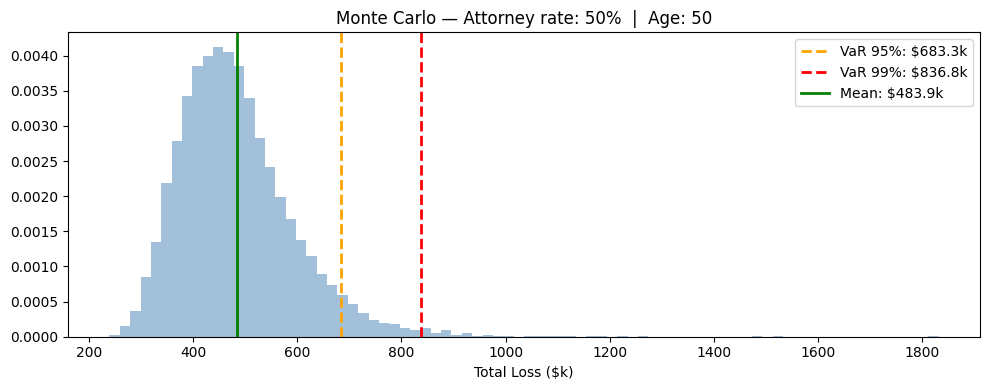

Mean expected loss:   $483.87k
VaR 95%:              $683.30k
VaR 99%:              $836.84k
Expected Shortfall:   $779.74k


In [ ]:
simulate(0.5,50)

In [ ]:
from ipywidgets import interact, FloatSlider, IntSlider
interact(
    simulate,
    p_attorney=FloatSlider(min=0, max=1, step=0.05, value=0.3, description='Attorney %'),
    age=IntSlider(min=18, max=80, step=1, value=40, description='CLMAGE')
)

interactive(children=(FloatSlider(value=0.3, description='Attorney %', max=1.0, step=0.05), IntSlider(value=40…

<function __main__.simulate(p_attorney, age)>

# GLM modeling

In [ ]:
import pandas as pd

# Convert to categorical
cat_vars = ['ATTORNEY', 'CLMSEX', 'MARITAL', 'CLMINSUR', 'SEATBELT']
for col in cat_vars:
    AutoBI[col] = AutoBI[col].astype('category')

# Check data
AutoBI.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1340 entries, 0 to 1339
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   Index     1340 non-null   int64   
 1   CASENUM   1340 non-null   int64   
 2   ATTORNEY  1340 non-null   category
 3   CLMSEX    1328 non-null   category
 4   MARITAL   1324 non-null   category
 5   CLMINSUR  1299 non-null   category
 6   SEATBELT  1292 non-null   category
 7   CLMAGE    1151 non-null   float64 
 8   LOSS      1340 non-null   float64 
dtypes: category(5), float64(2), int64(2)
memory usage: 49.2 KB


There seems to be some missing values for CLMSEX, MARTIAL status, CLIMINSUR, SEATBELT, and CLMAGE

In [ ]:
cat_vars = [ 'CLMSEX', 'MARITAL', 'CLMINSUR', 'SEATBELT']

for col in cat_vars:
    AutoBI[col] = AutoBI[col].cat.add_categories(['Missing'])
    AutoBI[col] = AutoBI[col].fillna('Missing')

In [ ]:
AutoBI.head()

,Index,CASENUM,ATTORNEY,CLMSEX,MARITAL,CLMINSUR,SEATBELT,CLMAGE,LOSS
0,1,5,1,1.0,Missing,2.0,1.0,50.0,34.940
1,2,13,2,2.0,2.0,1.0,1.0,28.0,10.892
2,3,66,2,1.0,2.0,2.0,1.0,5.0,0.330
3,4,71,1,1.0,1.0,2.0,2.0,32.0,11.037
4,5,96,2,1.0,4.0,2.0,1.0,30.0,0.138


In [ ]:
AutoBI['CLMAGE_missing'] = AutoBI['CLMAGE'].isna().astype(int)
AutoBI['CLMAGE'] = AutoBI['CLMAGE'].fillna(AutoBI['CLMAGE'].median())

In [ ]:
# Convert to categorical
cat_vars = ['ATTORNEY', 'CLMSEX', 'MARITAL', 'CLMINSUR', 'SEATBELT']
for col in cat_vars:
    AutoBI[col] = AutoBI[col].astype('category')

# Check data
AutoBI.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1340 entries, 0 to 1339
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   Index           1340 non-null   int64   
 1   CASENUM         1340 non-null   int64   
 2   ATTORNEY        1340 non-null   category
 3   CLMSEX          1340 non-null   category
 4   MARITAL         1340 non-null   category
 5   CLMINSUR        1340 non-null   category
 6   SEATBELT        1340 non-null   category
 7   CLMAGE          1340 non-null   float64 
 8   LOSS            1340 non-null   float64 
 9   CLMAGE_missing  1340 non-null   int64   
dtypes: category(5), float64(2), int64(3)
memory usage: 59.7 KB


In [ ]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

model1 = smf.glm(
    formula="""
    LOSS ~ C(ATTORNEY) + C(CLMSEX) + C(MARITAL) +
           C(CLMINSUR) + C(SEATBELT) +
           CLMAGE + CLMAGE_missing
    """,
    data=AutoBI,
    family=sm.families.Gamma(sm.families.links.log())
).fit()

print(model1.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                   LOSS   No. Observations:                 1340
Model:                            GLM   Df Residuals:                     1326
Model Family:                   Gamma   Df Model:                           13
Link Function:                    log   Scale:                          6.4043
Method:                          IRLS   Log-Likelihood:                -3912.3
Date:                Wed, 13 May 2026   Deviance:                       2253.6
Time:                        20:22:00   Pearson chi2:                 8.49e+03
No. Iterations:                    26   Pseudo R-squ. (CS):             0.1137
Covariance Type:            nonrobust                                         
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept                  1

/usr/local/lib/python3.12/dist-packages/statsmodels/genmod/families/links.py:13: FutureWarning: The log link alias is deprecated. Use Log instead. The log link alias will be removed after the 0.15.0 release.
  warnings.warn(


In [ ]:
print(model1.aic)

7852.692104332107



The strongest predictors in the model are:
*   attorney (p-value 0, coefficient -1.5687)
*   presence/absence of seatbelt  (p-value 0.081, coefficient 0.9534)
*   the claimiant's age (missing) (p-value 0.037, coefficient 0.5516)
*   the claimiant's age- this was used to preserve the observations. claimant's' age (missing was imputed)








The weakest predictors in this model are:
*   the claimiant's sex (high p-value and low coefficient value)
*   the claimiant's insurance status (high p-value and low coefficient value)



From this glm model, it looks like losses are lower if there is not an attorney present.
exp(−1.5687)≈0.21
Claims without an attorney have about 79% lower expected loss compared to claims with an attorney (baseline)
In addition, the absence of a seatbelt

In [ ]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

model2 = smf.glm(
    formula="""
    LOSS ~ C(ATTORNEY) + C(MARITAL) +
            + C(SEATBELT) +
           CLMAGE + CLMAGE_missing
    """,
    data=AutoBI,
    family=sm.families.Gamma(sm.families.links.log())
).fit()

print(model2.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/genmod/families/links.py:13: FutureWarning: The log link alias is deprecated. Use Log instead. The log link alias will be removed after the 0.15.0 release.
  warnings.warn(


                 Generalized Linear Model Regression Results                  
Dep. Variable:                   LOSS   No. Observations:                 1340
Model:                            GLM   Df Residuals:                     1330
Model Family:                   Gamma   Df Model:                            9
Link Function:                    log   Scale:                          6.6173
Method:                          IRLS   Log-Likelihood:                -3940.7
Date:                Wed, 13 May 2026   Deviance:                       2260.0
Time:                        20:22:00   Pearson chi2:                 8.80e+03
No. Iterations:                    22   Pseudo R-squ. (CS):             0.1096
Covariance Type:            nonrobust                                         
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept                  1

In [ ]:
print(model2.aic)

7901.48517099582


# Interaction variable

There were some interaction variables that I was curious about:
*   interaction between attorney involvement/presence and seatbelt on the severity of a loss




In [ ]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

model3 = smf.glm(
    formula="""
    LOSS ~ C(ATTORNEY) + C(MARITAL)
         + C(SEATBELT)
         + C(ATTORNEY) * C(SEATBELT)
         + CLMAGE + CLMAGE_missing
    """,
    data=AutoBI,
    family=sm.families.Gamma(sm.families.links.log())
).fit()

print(model3.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/genmod/families/links.py:13: FutureWarning: The log link alias is deprecated. Use Log instead. The log link alias will be removed after the 0.15.0 release.
  warnings.warn(


                 Generalized Linear Model Regression Results                  
Dep. Variable:                   LOSS   No. Observations:                 1340
Model:                            GLM   Df Residuals:                     1328
Model Family:                   Gamma   Df Model:                           11
Link Function:                    log   Scale:                          6.5418
Method:                          IRLS   Log-Likelihood:                -3930.5
Date:                Wed, 13 May 2026   Deviance:                       2254.8
Time:                        20:22:00   Pearson chi2:                 8.69e+03
No. Iterations:                    24   Pseudo R-squ. (CS):             0.1113
Covariance Type:            nonrobust                                         
                                              coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------

It looks like the interaction between seatbelt and the attorney was not statistically significant and the coefficient between them were not significantly strong either.

In [ ]:
print(model3.aic)

7885.057795581827


In [ ]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

model4 = smf.glm(
    formula="""
    LOSS ~ C(ATTORNEY) + C(MARITAL)
         + C(SEATBELT)
         + C(ATTORNEY) * C(CLMAGE) +
         + CLMAGE + CLMAGE_missing
    """,
    data=AutoBI,
    family=sm.families.Gamma(sm.families.links.log())
).fit()
#print(model4.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/genmod/families/links.py:13: FutureWarning: The log link alias is deprecated. Use Log instead. The log link alias will be removed after the 0.15.0 release.
  warnings.warn(


In [ ]:
print(model1.aic)
print(model2.aic)
print(model3.aic)
print(model4.aic)


7852.692104332107
7901.48517099582
7885.057795581827
7437.818843007837


In [ ]:
from sklearn.model_selection import train_test_split

train, test = train_test_split(AutoBI, test_size=0.3, random_state=42)

In [ ]:
import statsmodels.formula.api as smf
import statsmodels.api as sm

model4_train = smf.glm(
    formula="""
    LOSS ~ C(ATTORNEY) + C(MARITAL)
         + C(SEATBELT)
         + C(ATTORNEY) * C(CLMAGE) +
         + CLMAGE + CLMAGE_missing
    """,
    data=AutoBI,
    family=sm.families.Gamma(sm.families.links.log())
).fit()

/usr/local/lib/python3.12/dist-packages/statsmodels/genmod/families/links.py:13: FutureWarning: The log link alias is deprecated. Use Log instead. The log link alias will be removed after the 0.15.0 release.
  warnings.warn(


In [ ]:
import statsmodels.formula.api as smf
import statsmodels.api as sm

model1_train = smf.glm(
    formula="""
    LOSS ~ C(ATTORNEY) + C(CLMSEX) + C(MARITAL) +
           C(CLMINSUR) + C(SEATBELT) +
           CLMAGE + CLMAGE_missing
    """,
    data=AutoBI,
    family=sm.families.Gamma(sm.families.links.log())
).fit()

/usr/local/lib/python3.12/dist-packages/statsmodels/genmod/families/links.py:13: FutureWarning: The log link alias is deprecated. Use Log instead. The log link alias will be removed after the 0.15.0 release.
  warnings.warn(


In [ ]:
import statsmodels.formula.api as smf
import statsmodels.api as sm

model2_train = smf.glm(
    formula="""
    LOSS ~ C(ATTORNEY) + C(MARITAL) +
            + C(SEATBELT) +
           CLMAGE + CLMAGE_missing
    """,
    data=AutoBI,
    family=sm.families.Gamma(sm.families.links.log())
).fit()

/usr/local/lib/python3.12/dist-packages/statsmodels/genmod/families/links.py:13: FutureWarning: The log link alias is deprecated. Use Log instead. The log link alias will be removed after the 0.15.0 release.
  warnings.warn(


In [ ]:
import statsmodels.formula.api as smf
import statsmodels.api as sm

model3_train = smf.glm(
    formula="""
    LOSS ~ C(ATTORNEY) + C(MARITAL)
         + C(SEATBELT)
         + C(ATTORNEY) * C(SEATBELT)
         + CLMAGE + CLMAGE_missing
    """,
    data=AutoBI,
    family=sm.families.Gamma(sm.families.links.log())
).fit()

/usr/local/lib/python3.12/dist-packages/statsmodels/genmod/families/links.py:13: FutureWarning: The log link alias is deprecated. Use Log instead. The log link alias will be removed after the 0.15.0 release.
  warnings.warn(


In [ ]:
test["pred1"] = model1_train.predict(test)
test["pred2"] = model2_train.predict(test)
test["pred3"] = model3_train.predict(test)
test["pred4"] = model4_train.predict(test)

In [ ]:
import numpy as np

results = {
    "Model1_MAE": np.mean(np.abs(test["LOSS"] - test["pred1"])),
    "Model2_MAE": np.mean(np.abs(test["LOSS"] - test["pred2"])),
    "Model3_MAE": np.mean(np.abs(test["LOSS"] - test["pred3"])),
    "Model4_MAE": np.mean(np.abs(test["LOSS"] - test["pred4"]))
}

results

{'Model1_MAE': np.float64(7.479513562580778),
 'Model2_MAE': np.float64(7.486750326809026),
 'Model3_MAE': np.float64(7.483858467070794),
 'Model4_MAE': np.float64(7.345656571844475)}

In [ ]:
import pandas as pd
import numpy as np
from statsmodels.genmod.families import Gamma

summary = pd.DataFrame({
    "Model": ["Model1", "Model2", "Model3", "Model4"],

    # In-sample fit (AIC)
    "AIC": [
        model1_train.aic,
        model2_train.aic,
        model3_train.aic,
        model4_train.aic
    ],

    # Out-of-sample Gamma deviance
    "Test_Deviance": [
        Gamma().deviance(test["LOSS"], test["pred1"]),
        Gamma().deviance(test["LOSS"], test["pred2"]),
        Gamma().deviance(test["LOSS"], test["pred3"]),
        Gamma().deviance(test["LOSS"], test["pred4"]),
    ],

    # Out-of-sample MAE (easy interpretability)
    "Test_MAE": [
        np.mean(np.abs(test["LOSS"] - test["pred1"])),
        np.mean(np.abs(test["LOSS"] - test["pred2"])),
        np.mean(np.abs(test["LOSS"] - test["pred3"])),
        np.mean(np.abs(test["LOSS"] - test["pred4"])),
    ]
})

summary

,Model,AIC,Test_Deviance,Test_MAE
0,Model1,7852.692104,778.797092,7.479514
1,Model2,7901.485171,779.988538,7.486750
2,Model3,7885.057796,777.961800,7.483858
3,Model4,7437.818843,617.997229,7.345657
